In [1]:
import xarray as xr
import matplotlib.pyplot as plt
import numpy as np
import os

/home/nilsmk/.conda/envs/nils_production-10-2022_rhel8/lib/python3.9/site-packages/scipy/__init__.py:155: UserWarning: A NumPy version >=1.18.5 and <1.25.0 is required for this version of SciPy (detected version 1.26.4
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


In [2]:
read_one_case = True

In [3]:
# # First tries:
# # ifile = '/lustre/storeB/users/nilsmk/anemoi-datasets/output/first_try/inference/lam-48h.nc'
# ifile = '/lustre/storeB/users/nilsmk/anemoi-datasets/output/first_try/inference/lam-240h.nc'
# odir  = '/lustre/storeB/users/nilsmk/anemoi-datasets/output/first_try/inference/figures/'
# comparewith = '/lustre/storeB/users/nilsmk/stormrisk/nora3_v2/1980/ocean_his.nc'

In [ ]:
if read_one_case:
    # Xaver case:
    step = '057000'
    # ifile = f'/lustre/storeB/users/nilsmk/anemoi-datasets/output/longrun_10years/inference/xaver_2013-12-01_240h_step{step}.nc'
    # odir  = '/lustre/storeB/users/nilsmk/anemoi-datasets/output/longrun_10years/inference/figures/xaver_case'
    # ifile = f'/lustre/storeB/users/nilsmk/anemoi-datasets/output/longrun_10years_newgraph/inference/xaver_2013-12-01_240h_step{step}.nc'
    # odir  = '/lustre/storeB/users/nilsmk/anemoi-datasets/output/longrun_10years_newgraph/inference/figures/xaver_case'
    ifile = f'/lustre/storeB/users/nilsmk/anemoi-datasets/output/longrun_10years_newgraph_90s_uncorr/inference/xaver_2013-12-01_240h_step{step}.nc'
    odir  = '/lustre/storeB/users/nilsmk/anemoi-datasets/output/longrun_10years_newgraph_90s_uncorr/inference/figures/xaver_case'
    # ifile = f'/lustre/storeB/users/nilsmk/anemoi-datasets/output/longrun_10years_newgraph_90s_corrected/inference/xaver_2013-12-01_240h_step{step}.nc'
    # odir  = '/lustre/storeB/users/nilsmk/anemoi-datasets/output/longrun_10years_newgraph_90s_corrected/inference/figures/xaver_case'
    prefix = f'step{step}_'
else:
    odir = '/lustre/storeB/users/nilsmk/anemoi-datasets/output/longrun_10years/inference/figures/'
    # prefix = 'allruns2013_step112k_'
    prefix = 'allruns2013_step75k_'
comparewith = '/lustre/storeB/users/nilsmk/stormrisk/nora3_v2/2013/ocean_his.nc'
comparewith2 = '/lustre/storeB/users/nilsmk/stormrisk/nora3_v2_corrected/2013/ocean_his.nc'

In [5]:
# Create odir if it does not exist
import os
if not os.path.exists(odir):
    os.makedirs(odir)

In [6]:
if read_one_case:
    nc = xr.open_dataset(ifile)
    zeta = nc.zeta
    lat = nc.latitude
    lon = nc.longitude
    time = nc.time
    # x_wind_10m = nc.x_wind_10m
    #
    zeta2 = np.reshape(zeta.values, (zeta.shape[0], 570, 1014))
    lat2 = np.reshape(lat.values, (570, 1014))
    lon2 = np.reshape(lon.values, (570, 1014))
    # x_wind_10m2 = np.reshape(x_wind_10m.values, (x_wind_10m.shape[0], 570, 1014))

/home/nilsmk/.conda/envs/nils_production-10-2022_rhel8/lib/python3.9/site-packages/xarray/backends/plugins.py:64: RuntimeWarning: Engine 'gini' loading failed:
cannot import name 'deprecated' from 'typing_extensions' (/home/nilsmk/.conda/envs/nils_production-10-2022_rhel8/lib/python3.9/site-packages/typing_extensions.py)
  warnings.warn(f"Engine {name!r} loading failed:\n{ex}", RuntimeWarning)


In [7]:
nc_c = xr.open_dataset(comparewith)
zeta_c = nc_c.zeta[:,5:575,5:1019]  # cut away the outermost grid cells to match the lam grid
lat_c = nc_c.lat_rho[5:575,5:1019]
lon_c = nc_c.lon_rho[5:575,5:1019]
time_c = nc_c.ocean_time
mask_c = nc_c.mask_rho[5:575,5:1019]
timee_c = np.array([np.datetime64(t) for t in time_c.values])
if 'comparewith2' in locals():
    nc_c2 = xr.open_dataset(comparewith2)
    zeta_c2 = nc_c2.zeta[:,5:575,5:1019]  # cut away the outermost grid cells to match the lam grid

In [8]:
if read_one_case:
    # Find index of time in time_c
    timee = np.array([np.datetime64(t) for t in time.values])
    timee_c = np.array([np.datetime64(t) for t in time_c.values])
    time_indices = np.where((timee_c >= timee[0]) & (timee_c <= timee[-1]))[0]

In [9]:
if read_one_case:
    import warnings
    warnings.filterwarnings('ignore', category=UserWarning) # Suppress UserWarnings
    # Plot the same as above, but with two subplots, one for the inference and one for the comparison
    minval = -2
    maxval = 2
    colormap = 'RdBu_r'
    # for i in range(0, len(time), 2):
    for i in range(0, 180, 3):
        fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15, 5), sharey=True)
        # sc1 = ax1.scatter(lon[:], lat[:], c=zeta[i, :], cmap=colormap, s=0.1, vmin=minval, vmax=maxval)
        # ax1.set_title(f'Inference\nTime index: {i}, Time value: {time[i]}')
        # fig.colorbar(sc1, ax=ax1, label='zeta[m]')
        # sc2 = ax2.scatter(lon_c[:], lat_c[:], c=zeta_c[time_indices[i], :, :].values.flatten(), cmap=colormap, s=0.1, vmin=minval, vmax=maxval)
        # ax2.set_title(f'Comparison\nTime index: {time_indices[i]}, Time value: {timee_c[time_indices[i]]}')
        # fig.colorbar(sc2, ax=ax2, label='zeta[m]')
        pcm1 = ax1.pcolormesh(lon2, lat2, zeta2[i,:,:], cmap=colormap, vmin=minval, vmax=maxval)
        ax1.set_title(f'Inference\nTime index: {i}')
        fig.colorbar(pcm1, ax=ax1, label='zeta[m]')
        pcm2 = ax2.pcolormesh(lon_c, lat_c, zeta_c[time_indices[i], :, :]*mask_c, cmap=colormap, vmin=minval, vmax=maxval)
        ax2.set_title(f'Comparison\nTime index: {time_indices[i]}, Time value: {timee_c[time_indices[i]]}')
        fig.colorbar(pcm2, ax=ax2, label='zeta[m]')
        pcm3 = ax3.pcolormesh(lon_c, lat_c, zeta2[i,:,:]-zeta_c[time_indices[i], :, :]*mask_c, cmap='bwr', vmin=-1, vmax=1)
        ax3.set_title(f'Difference\nTime index: {i}')
        fig.colorbar(pcm3, ax=ax3, label='zeta[m]')
        plt.tight_layout()
        plt.savefig(os.path.join(odir, f'{prefix}zeta_compare_{i:03d}.png'), dpi=100)
        # plt.show()
        plt.close()
        print(f'Plotted index {i}, number of plots left: {len(time)-i-1}')

Plotted index 0, number of plots left: 240
Plotted index 3, number of plots left: 237
Plotted index 6, number of plots left: 234
Plotted index 9, number of plots left: 231
Plotted index 12, number of plots left: 228
Plotted index 15, number of plots left: 225
Plotted index 18, number of plots left: 222
Plotted index 21, number of plots left: 219
Plotted index 24, number of plots left: 216
Plotted index 27, number of plots left: 213
Plotted index 30, number of plots left: 210
Plotted index 33, number of plots left: 207
Plotted index 36, number of plots left: 204
Plotted index 39, number of plots left: 201
Plotted index 42, number of plots left: 198
Plotted index 45, number of plots left: 195
Plotted index 48, number of plots left: 192
Plotted index 51, number of plots left: 189
Plotted index 54, number of plots left: 186
Plotted index 57, number of plots left: 183
Plotted index 60, number of plots left: 180
Plotted index 63, number of plots left: 177
Plotted index 66, number of plots le

In [10]:
if read_one_case:
    # Using "convert" in os.system to create a gif from the png files
    os.system(f'convert -delay 10 -loop 0 {odir}/{prefix}zeta_compare*.png {odir}/{prefix}zeta_xaver.gif')
    print(f'{odir}/{prefix}zeta_xaver.gif created successfully.')

/lustre/storeB/users/nilsmk/anemoi-datasets/output/longrun_10years_newgraph_90s_corrected/inference/figures/xaver_case/step056000_zeta_xaver.gif created successfully.


In [11]:
# LIst all the gif files in odir
gif_files = [f for f in os.listdir(odir) if f.endswith('.gif')]
print('GIF files in output directory:')
for gif in gif_files:
    print(os.path.join(odir, gif))

GIF files in output directory:
/lustre/storeB/users/nilsmk/anemoi-datasets/output/longrun_10years_newgraph_90s_corrected/inference/figures/xaver_case/step040000_zeta_xaver.gif
/lustre/storeB/users/nilsmk/anemoi-datasets/output/longrun_10years_newgraph_90s_corrected/inference/figures/xaver_case/step056000_zeta_xaver.gif


TODO: Plot timseries for all runs, start with Cuxhaven

In [12]:
if read_one_case:
    # Cuxhaven coordinates
    sta_lat = 53.87
    sta_lon = 8.72
    staname = 'Cuxhaven'
    # Oscarsborg coordinates 66 NO_OSC 59.678074 10.604861
    # sta_lat = 59.68
    # sta_lon = 10.60
    # staname = 'Oscarsborg'
    # Bergen coordinates 53 NO_BGO 60.398045 5.320487
    # sta_lat = 60.40
    # sta_lon = 5.32
    # staname = 'Bergen'
    # Do the same for the comparison data
    lat_c_arr = np.array(lat_c[:])
    lon_c_arr = np.array(lon_c[:])
    dist_c = np.sqrt((lat_c_arr - sta_lat)**2 + (lon_c_arr - sta_lon)**2)
    min_index_c = np.unravel_index(np.argmin(dist_c), dist_c.shape)
    print(f'Nearest point to {staname} in comparison data: lat={lat_c_arr[min_index_c]}, lon={lon_c_arr[min_index_c]} at index {min_index_c}')
    # If land point, find new position:
    if mask_c[min_index_c] == 0:
        print('Nearest point is on land, searching for nearest sea point...')
        sea_indices = np.where(mask_c == 1)
        sea_lats = lat_c_arr[sea_indices]
        sea_lons = lon_c_arr[sea_indices]
        dist_sea = np.sqrt((sea_lats - sta_lat)**2 + (sea_lons - sta_lon)**2)
        min_sea_index = np.argmin(dist_sea)
        min_index_c = (sea_indices[0][min_sea_index], sea_indices[1][min_sea_index])
        print(f'New nearest sea point: lat={lat_c_arr[min_index_c]}, lon={lon_c_arr[min_index_c]} at index {min_index_c}')
        # Update sta_lat and sta_lon
        sta_lat = lat_c_arr[min_index_c]
        sta_lon = lon_c_arr[min_index_c]
    # Find the nearest point in the lat/lon grid
    import numpy as np
    lat_arr = np.array(lat[:])
    lon_arr = np.array(lon[:])
    dist = np.sqrt((lat_arr - sta_lat)**2 + (lon_arr - sta_lon)**2)
    min_index = np.unravel_index(np.argmin(dist), dist.shape)
    print(f'Nearest point to {staname}: lat={lat_arr[min_index]}, lon={lon_arr[min_index]} at index {min_index}')

Nearest point to Cuxhaven in comparison data: lat=53.877716064453125, lon=8.72961711883545 at index (1, 259)
Nearest point is on land, searching for nearest sea point...
New nearest sea point: lat=53.926902770996094, lon=8.723377227783203 at index (2, 260)
Nearest point to Cuxhaven: lat=53.926902770996094, lon=8.723377227783203 at index (2288,)


In [13]:
# plt.pcolormesh(mask_c[min_index_c[0]-5:min_index_c[0]+5, min_index_c[1]-5:min_index_c[1]+5], cmap='gray')

In [25]:
import glob
# ifiles = glob.glob('/lustre/storeB/users/nilsmk/anemoi-datasets/output/longrun_10years_newgraph_90*/inference/xaver_2013-12-01_240h_step*.nc')
ifiles = glob.glob('/lustre/storeB/users/nilsmk/anemoi-datasets/output/longrun_10years_newgraph_90s_corr*/inference/xaver_2013-12-01_240h_step*.nc')
# ifiles = glob.glob('/lustre/storeB/users/nilsmk/anemoi-datasets/output/longrun_10years_new*/inference/xaver_2013-12-01_240h_step*.nc')
# ifiles = glob.glob('/lustre/storeB/users/nilsmk/anemoi-datasets/output/longrun_10years/inference/????-??-??_240h_step112000.nc')
# ifiles = glob.glob('/lustre/storeB/users/nilsmk/anemoi-datasets/output/longrun_10years/inference/????-??-??_240h_step075000.nc')
ifiles.sort()


In [26]:
for ifile in ifiles:
    print(f'Processing file: {ifile}')

Processing file: /lustre/storeB/users/nilsmk/anemoi-datasets/output/longrun_10years_newgraph_90s_corrected/inference/xaver_2013-12-01_240h_step040000.nc
Processing file: /lustre/storeB/users/nilsmk/anemoi-datasets/output/longrun_10years_newgraph_90s_corrected/inference/xaver_2013-12-01_240h_step056000.nc


RMSE for step 040000: 0.5227 m
RMSE for step 056000: 0.3976 m


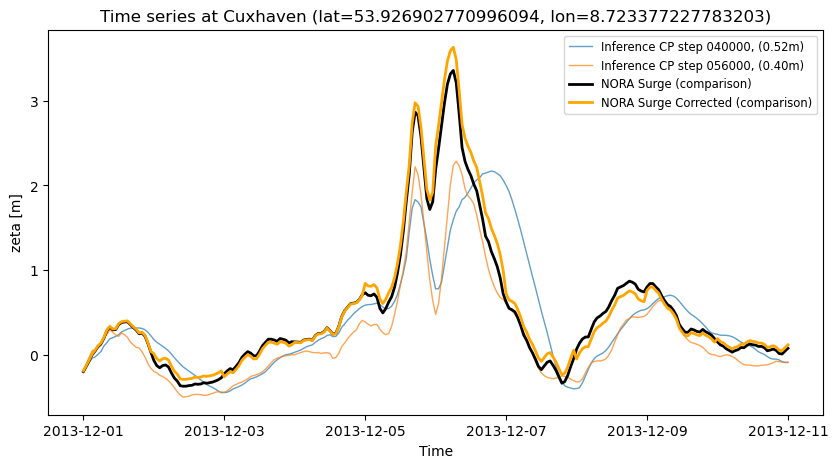

In [27]:
# Plot the time series for the station for all inference runs and the comparison data in one plot
fig, ax = plt.subplots(figsize=(10, 5))
for file in ifiles:
    nc = xr.open_dataset(file)
    zeta = nc.zeta
    time = nc.time
    # Calculate RMSE for this time series compared to the comparison data
    zeta_c_series = zeta_c[time_indices, min_index_c[0], min_index_c[1]].values
    zeta_series = zeta[:, min_index[0]].values
    rmse = np.sqrt(np.mean((zeta_series - zeta_c_series)**2))
    print(f'RMSE for step {file[-9:-3]}: {rmse:.4f} m')
    ax.plot(time, zeta[:, min_index[0]], label=f'Inference CP step {file[-9:-3]}, ({rmse:.2f}m)', lw=1, alpha=0.7)
# Plot the comparison data time series
ax.plot(time_c[time_indices], zeta_c[time_indices, min_index_c[0], min_index_c[1]], label='NORA Surge (comparison)', lw=2, color='k')
if 'comparewith2' in locals():
    ax.plot(time_c[time_indices], zeta_c2[time_indices, min_index_c[0], min_index_c[1]], label='NORA Surge Corrected (comparison)', lw=2, color='orange')
ax.set_title(f'Time series at {staname} (lat={sta_lat}, lon={sta_lon})')
ax.set_xlabel('Time')
ax.set_ylabel('zeta [m]')
ax.legend(fontsize='small')
plt.savefig(os.path.join(odir, f'{prefix}zeta_timeseries_{staname}.png'), dpi=100)
plt.show()

RMSE for step 040000: 0.5227 m


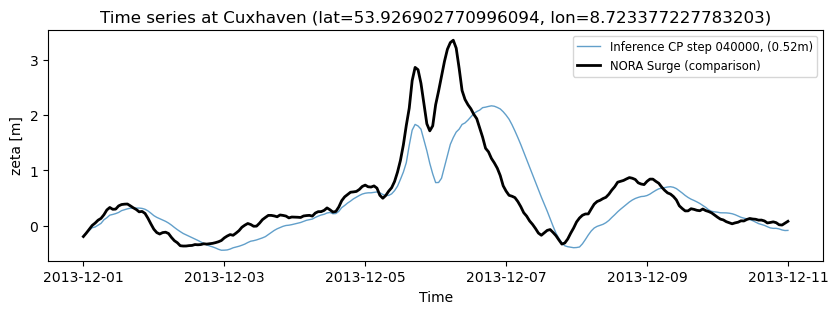

RMSE for step 056000: 0.3976 m


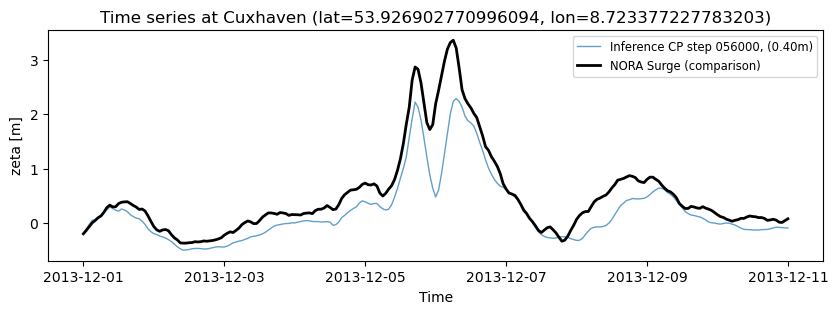

In [28]:
if True:
    # Plot the individual time series
    for file in ifiles:
        fig, ax = plt.subplots(figsize=(10, 3))
        nc = xr.open_dataset(file)
        zeta = nc.zeta
        time = nc.time
        # Calculate RMSE for this time series compared to the comparison data
        zeta_c_series = zeta_c[time_indices, min_index_c[0], min_index_c[1]].values
        zeta_series = zeta[:, min_index[0]].values
        rmse = np.sqrt(np.mean((zeta_series - zeta_c_series)**2))
        print(f'RMSE for step {file[-9:-3]}: {rmse:.4f} m')
        ax.plot(time, zeta[:, min_index[0]], label=f'Inference CP step {file[-9:-3]}, ({rmse:.2f}m)', lw=1, alpha=0.7)
        # Plot the comparison data time series
        ax.plot(time_c[time_indices], zeta_c[time_indices, min_index_c[0], min_index_c[1]], label='NORA Surge (comparison)', lw=2, color='k')
        ax.set_title(f'Time series at {staname} (lat={sta_lat}, lon={sta_lon})')
        ax.set_xlabel('Time')
        ax.set_ylabel('zeta [m]')
        ax.legend(fontsize='small')
        # plt.savefig(os.path.join(odir, f'{prefix}zeta_timeseries_{staname}.png'), dpi=100)
        plt.show()

In [29]:
# Calulate RMSE between inference and NORA surge for all time steps for all runs, and plot as time series
rmse = np.zeros((len(ifiles), len(time)))
for ifile_idx, ifile in enumerate(ifiles):
    print(f'Processing file: {ifile}')
    nc = xr.open_dataset(ifile)
    zeta = nc.zeta
    zeta2 = np.reshape(zeta.values, (zeta.shape[0], 570, 1014))
    for i in range(len(time)):
        rmse[ifile_idx, i] = np.sqrt(np.mean((zeta2[i,:,:]-zeta_c[time_indices[i], :, :]*mask_c)**2))


Processing file: /lustre/storeB/users/nilsmk/anemoi-datasets/output/longrun_10years_newgraph_90s_corrected/inference/xaver_2013-12-01_240h_step040000.nc
Processing file: /lustre/storeB/users/nilsmk/anemoi-datasets/output/longrun_10years_newgraph_90s_corrected/inference/xaver_2013-12-01_240h_step056000.nc


RMSE time series plot saved to /lustre/storeB/users/nilsmk/anemoi-datasets/output/longrun_10years_newgraph_90s_corrected/inference/figures/xaver_case/step056000_zeta_rmse_timeseries.png


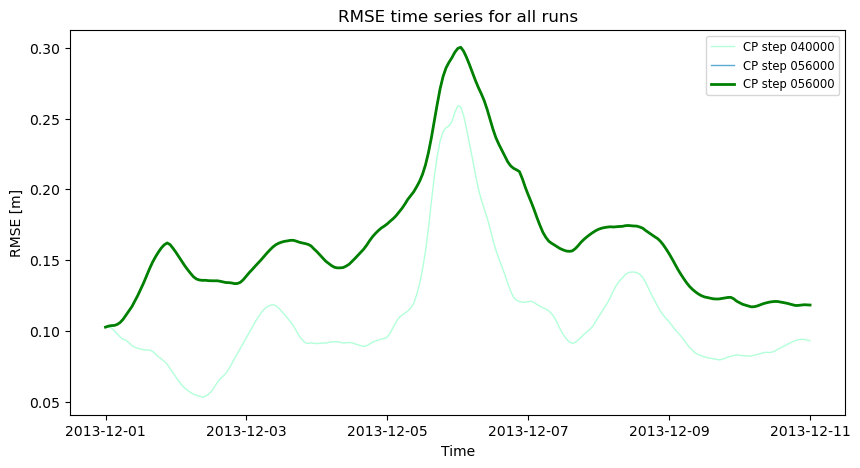

In [30]:
# Plot the RMSE time series for all runs, color them by the CP step using viridis colormap
import matplotlib.cm as cm
fig, ax = plt.subplots(figsize=(10, 5))
for ifile_idx, ifile in enumerate(ifiles):
    # alpha = (ifile_idx+1)/len(ifiles)
    alpha = 0.3 + 0.7*(ifile_idx/len(ifiles))
    color = cm.winter_r(ifile_idx/len(ifiles))
    ax.plot(time, rmse[ifile_idx, :], label=f'CP step {ifile[-9:-3]}', lw=1, alpha=alpha, color=color)
    if ifile_idx == len(ifiles)-1:
        ax.plot(time, rmse[ifile_idx, :], label=f'CP step {ifile[-9:-3]}', lw=2, color='g')
ax.set_title(f'RMSE time series for all runs')
ax.set_xlabel('Time')
ax.set_ylabel('RMSE [m]')
ax.legend(fontsize='small')
plt.savefig(os.path.join(odir, f'{prefix}zeta_rmse_timeseries.png'), dpi=100)
print(f'RMSE time series plot saved to {os.path.join(odir, f"{prefix}zeta_rmse_timeseries.png")}')
plt.show()

### Do one year of data

In [31]:
if False:
    # Calulate RMSE between inference and NORA surge for all time steps for all runs
    for ifile_idx, ifile in enumerate(ifiles):
        print(f'Processing file: {ifile}')
        nc = xr.open_dataset(ifile)
        zeta = nc.zeta
        zeta2 = np.reshape(zeta.values, (zeta.shape[0], 570, 1014))
        time = nc.time
        if ifile_idx == 0:
            rmse = np.zeros((len(ifiles), len(time)))
        # Find index of time in time_c
        timee = np.array([np.datetime64(t) for t in time.values])
        time_indices = np.where((timee_c >= timee[0]) & (timee_c <= timee[-1]))[0]
        for i in range(len(time)):
            rmse[ifile_idx, i] = np.sqrt(np.mean((zeta2[i,:,:]-zeta_c[time_indices[i], :, :]*mask_c)**2))


In [32]:
# Store the rmse array as a pandas DataFrame and save as csv file
if not read_one_case:
    import pandas as pd
    csv_file = os.path.join(odir, f'{prefix}zeta_rmse_timeseries.csv')
    if not os.path.isfile(csv_file):
        rmse_df = pd.DataFrame(rmse, index=[ifile[-29:-19] for ifile in ifiles], columns=[str(t) for t in np.arange(time.shape[0])])
        rmse_df.to_csv(csv_file)
        print(f'RMSE time series saved to {os.path.join(odir, f"{prefix}zeta_rmse_timeseries.csv")}')
    else:
        print(f'CSV file {csv_file} already exists. Skipping saving.')
        rmse_df = pd.read_csv(csv_file, index_col=0)

In [33]:
# Plot the RMSE time series for all runs, color them by the CP step using viridis colormap
if not read_one_case:
    import matplotlib.cm as cm
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.plot(np.arange(rmse_df.shape[1]), np.median(rmse_df, axis=0), label=f'RMSE', lw=1)
    ax.set_title(f'RMSE time series for all runs')
    ax.set_xlabel('Time')
    ax.set_ylabel('RMSE [m]')
    # ax.legend(fontsize='small')
    plt.savefig(os.path.join(odir, f'{prefix}zeta_rmse_timeseries.png'), dpi=100)
    print(f'RMSE time series plot saved to {os.path.join(odir, f"{prefix}zeta_rmse_timeseries.png")}')
    plt.show()

In [34]:
# Plot the RMSE time series for all runs, color them by the CP step using viridis colormap
if not read_one_case:
    import matplotlib.cm as cm
    fig, ax = plt.subplots(figsize=(10, 5))
    for ifile_idx in np.arange(rmse_df.shape[0]):
        ax.plot(np.arange(rmse_df.shape[1]), rmse_df.values[ifile_idx, :], lw=1, color=cm.magma_r(ifile_idx/rmse_df.shape[0]))
    ax.set_title(f'RMSE time series for all runs')
    ax.set_xlabel('Time')
    ax.set_ylabel('RMSE [m]')
    plt.show()

In [35]:
# Plot rmse_df as pcolormesh
if not read_one_case:
    fig, ax = plt.subplots(figsize=(10, 5))
    pcm = ax.pcolormesh(rmse_df.columns.astype(int), rmse_df.index, rmse_df.values, cmap='plasma_r')
    ax.set_title(f'RMSE time series for all runs')
    ax.set_xlabel('Time')
    ax.set_ylabel('Run index')
    fig.colorbar(pcm, ax=ax, label='RMSE [m]')
    plt.show()